In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
assert os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] == "false"

import sys
sys.path.append('../')
sys.path.append('../../')

import ATLAS

import json, pickle
from glob import glob
from tqdm import tqdm

import numpy as np
from matplotlib import pyplot as plt

from functools import partial
import jax.numpy as jnp
import jax.random as jrandom

from ATLAS.utils import jit, jit_method, get_pulsar_timespan
from ATLAS.utils import jagged2padded
from ATLAS.signals.signals_utils import _timing_model_svd, get_fourier_design_matrix

import numpyro
import numpyro.distributions as dist

sim_path = '../../datasets/sim_NG15_01'
with open(sim_path+'/injected_params.json', 'r') as f:
    injected_params = json.load(f)

JAX 64-bit mode automatically enabled successfully.


/home/kyleg/miniforge3/envs/atlas/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from ATLAS.pulsar import load_pulsars
from ATLAS.data import PTA_Data

offset = 10
npsrs = 2

with open(sim_path+'/atlas_psrs.pkl','rb') as f:
    psrs = pickle.load(f)[offset:offset+npsrs]

data = PTA_Data(psrs, fixed_res = False, marg_timing = False, 
                diag_white_cov = False, linear_timing = True)


libstempo not installed. PINT or libstempo are required to use par and tim files.


In [3]:
binary_priors = {
    'PB': lambda x: dist.Uniform(0.05, 500).log_prob(x), # Orbital period (days)
    'PBDOT': lambda x: dist.Uniform(-1e-10, 1e-10).log_prob(x), # Time derivative of orbital period
    'A1': lambda x: dist.Uniform(0, 150).log_prob(x), # Projected semi-major axis (light-seconds)
    'A1DOT': lambda x: dist.Uniform(-1e-10, 1e-10).log_prob(x), # Time derivative of A1
#    'T0':       None, # Use _DT0 to derive     # Epoch of periastron passage (MJD)
#    'TASC':     None, # Use _DTASC to derive   # Epoch of ascending node passage (MJD)
    'ECC': lambda x: dist.Uniform(0, 1).log_prob(x), # Orbital eccentricity
    'EDOT': lambda x: dist.Uniform(-1e-10, 0).log_prob(x), # Time derivative of eccentricity
    'OM': lambda x: dist.Uniform(-360, 360).log_prob(x), # Longitude of periastron (deg)
    'OMDOT': lambda x: dist.Uniform(-3, 3).log_prob(x), # Time derivative of OM
    'EPS1': lambda x: dist.Uniform(-1, 1).log_prob(x), # Laplace-Lagrange parameter e*sin(omega)
    'EPS2': lambda x: dist.Uniform(-1, 1).log_prob(x), # Laplace-Lagrange parameter e*cos(omega)
    # Special SINI prior
    'SINI': lambda x: jnp.where(jnp.abs(x)<1, jnp.log(x/jnp.sqrt(1-x**2)), -jnp.inf), 
    'M2': lambda x: dist.TruncatedNormal(loc=0.214, scale=0.25, 
                low=0, high=1).log_prob(x),                 # Companion mass (solar masses)
    'KIN': lambda x: dist.Uniform(0, 360).log_prob(x),           # Inclination angle (deg), used by DDK
    'KOM': lambda x: dist.Uniform(-180, 180).log_prob(x),        # Longitude of ascending node (deg), used by DDK
    'H3': lambda x: dist.Uniform(-1e-6, 1e-6).log_prob(x),      # Orthometric Shapiro delay amplitude
    'FB0': lambda x: dist.Uniform(0, 1).log_prob(x),             # Orbital frequency and derivatives (ELL1)
    'FB1': lambda x: dist.Uniform(-1e-15, 1e-15).log_prob(x),     
    'FB2': lambda x: dist.Uniform(-1e-15, 1e-15).log_prob(x),
    'FB3': lambda x: dist.Uniform(-1e-15, 1e-15).log_prob(x),
    'FB4': lambda x: dist.Uniform(-1e-15, 1e-15).log_prob(x),
    'FB5': lambda x: dist.Uniform(-1e-15, 1e-15).log_prob(x),
}

class psr_TM:
    def __init__(self, psr, z_inflate=1e9):
        self.name = psr.name
        self.resids = psr.residuals
        self.M = psr.Mmat # (ntoa, npar)
        self.M_labels = np.array(psr.Mmat_labels) # (npar,)
        self.M_theta = jnp.insert(psr.fit_param_values, 0, 0) # Best fit values (npar,) [add 0 for offset]
        self.M_sigma = jnp.insert(psr.fit_param_uncertainties, 0, 0) # uncertainties on theta (npar,) [add 0 for offset]
        self.M_npar = self.M.shape[1] # Number of parameters (npar,)

        self.is_binary = jnp.array([l in binary_priors for l in self.M_labels]) # if the parameters are binary (npar,)

        self.Mb = self.M[:,self.is_binary] # M matrix of only binary (ntoa, npar_binary)
        self.Mb_labels = self.M_labels[self.is_binary] # Labels of binary parameters (npar_binary)
        self.Mb_theta = self.M_theta[self.is_binary] # Best fit values of binary parameters (npar_binary,)
        self.Mb_sigma = self.M_sigma[self.is_binary] # Uncertainties of binary parameters (npar_binary,)
        self.Mb_npar = self.Mb.shape[1] # Number of binary parameters (npar_binary,)

        self.Mo = self.M[:,~self.is_binary] # Everything else (ntoa, npar_other)
        self.Uo = _timing_model_svd(self.Mo) # SVD of non-binary timing model matrix (ntoa, npar_other)
        self.Mo_labels = self.M_labels[~self.is_binary] # Labels of non-binary parameters (npar_other)
        self.Mo_theta = self.M_theta[~self.is_binary] # Best fit values of non-binary parameters (npar_other,)
        self.Mo_sigma = self.M_sigma[~self.is_binary] # Uncertainties of non-binary parameters (npar_other,)
        self.Mo_npar = self.Mo.shape[1] # Number of non-binary parameters (npar_other,)

        self.z_inflate = z_inflate
        self.z_dist = dist.Normal(0, self.z_inflate).expand((self.Mb_npar,))

    def get_stuff(self):
        # Get z_binary
        zb = numpyro.sample(f'{self.name}_zb', self.z_dist) # (npar_binary,)

        # Compute the prior on zb to subtract from the likelihood
        zb_lnprior = jnp.sum(self.z_dist.log_prob(zb))
        numpyro.factor(f'{self.name}_zb_neg_prior', -zb_lnprior)

        # Convert z to epsilon
        epsilonb = zb * self.Mb_sigma # (npar_binary,)
        # Convert epsilon to theta and save
        thetab = self.Mb_theta + epsilonb # (npar_binary,)
        numpyro.deterministic(f'{self.name}_thetab', thetab)

        # Compute the prior on theta_binary and add to the likelihood
        thetab_lnprior = jnp.sum(jnp.array([binary_priors[l](t) for l, t in zip(self.Mb_labels, thetab)]))
        numpyro.factor(f'{self.name}_thetab_prior', thetab_lnprior)

        # Compute the residuals given epsilon_b
        r = self.resids - self.Mb @ epsilonb # (ntoa,)

        return r


    

class TM:
    def __init__(self, psrs, z_inflate=1e9):
        self.per_psr_TM = [psr_TM(p, z_inflate) for p in psrs]
        self.npsrs = len(psrs)

    def get_Mo(self):
        return [tm.Mo for tm in self.per_psr_TM]

    def get_stuff(self):
        r = [tm.get_stuff() for tm in self.per_psr_TM]
        return jnp.concatenate(r)


TM = TM(psrs)
data.add_timing_design_matrix(TM.get_Mo())

In [4]:

from ATLAS.psd_functions import powerlaw, free_spectrum, hd_orf
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils

## White Noise Model
wn_model = WhiteCov(data = data, stabilize_TNT = True)
wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds() #white noise prior bounds

## Red Noise Model
non_gwb_nfreqs = 30
gwb_nfreqs = 14
sig_unc = Red(name='unc',
            psd_function = partial(powerlaw),
            nfreqs=non_gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data,
            use_pulsar_tspan = False)

# GWB model
sig_cor = Correlated(name='cor',
            psd_function = partial(powerlaw),
            orf_function = hd_orf,
            nfreqs=gwb_nfreqs,
            lower_bound_psd = jnp.array([-18., 0.]),
            upper_bound_psd = jnp.array([-11., 1.]),
            data = data)

# Combined model
sig = SuperSignal(signal_list = [sig_unc],#, sig_cor],
                signal_combination_string = "ltm|unc->unc",
                data=data)


Construncting the white noise cov matrix for J0610-2100: 100%|██████████| 2/2 [00:00<00:00,  3.99it/s]


In [5]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value, init_to_uniform

from ATLAS.samplers.canetoadracing import MultiHMCGibbs

theta_wn_dist = dist.Uniform(wn_lower_bound, wn_upper_bound)
xs_dist = dist.Uniform(sig.model.lower_prior_lim_all, sig.model.upper_prior_lim_all)
z_a_dist = dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))

def model():
    # Timing model
    r = TM.get_stuff()

    ######################################## White Noise ########################################
    theta_wn = numpyro.sample('theta_wn', theta_wn_dist)
    helpers_now = sig.get_helpers(reff = r, white_noise_params=theta_wn)

    ######################################## Red Noise ########################################
    xs = numpyro.sample('xs', xs_dist) #PSD params
    z_a = numpyro.sample('z_a', z_a_dist) #the reparam coefficients

    lprob, coeff = sig.lnposterior_reparam(helpers = helpers_now, red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2)) # remove the prior on z_a


kernel = NUTS(model=model, max_tree_depth=12)

mcmc = MCMC(sampler=kernel, num_warmup=500, num_samples=2000)

mcmc.run(jrandom.PRNGKey(170817))
samples = mcmc.get_samples()

samples.keys()

sample: 100%|██████████| 2500/2500 [03:59<00:00, 10.45it/s, 31 steps of size 1.19e-01. acc. prob=0.93]


dict_keys(['J0605+3757_thetab', 'J0605+3757_zb', 'J0610-2100_thetab', 'J0610-2100_zb', 'theta_wn', 'xs', 'z_a'])

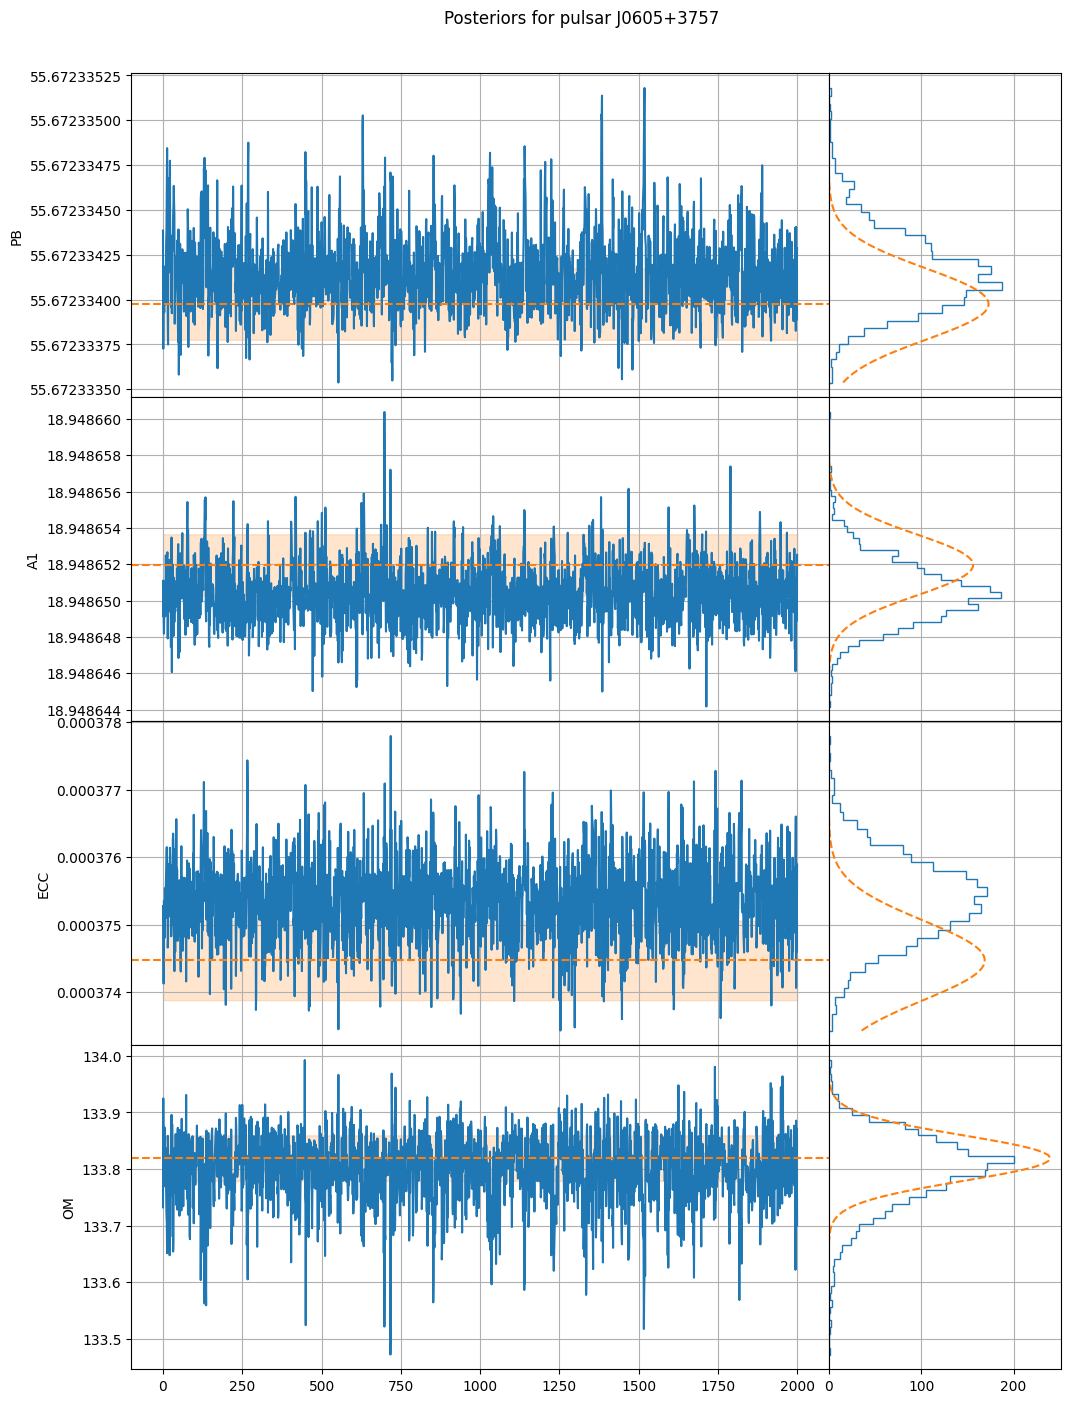

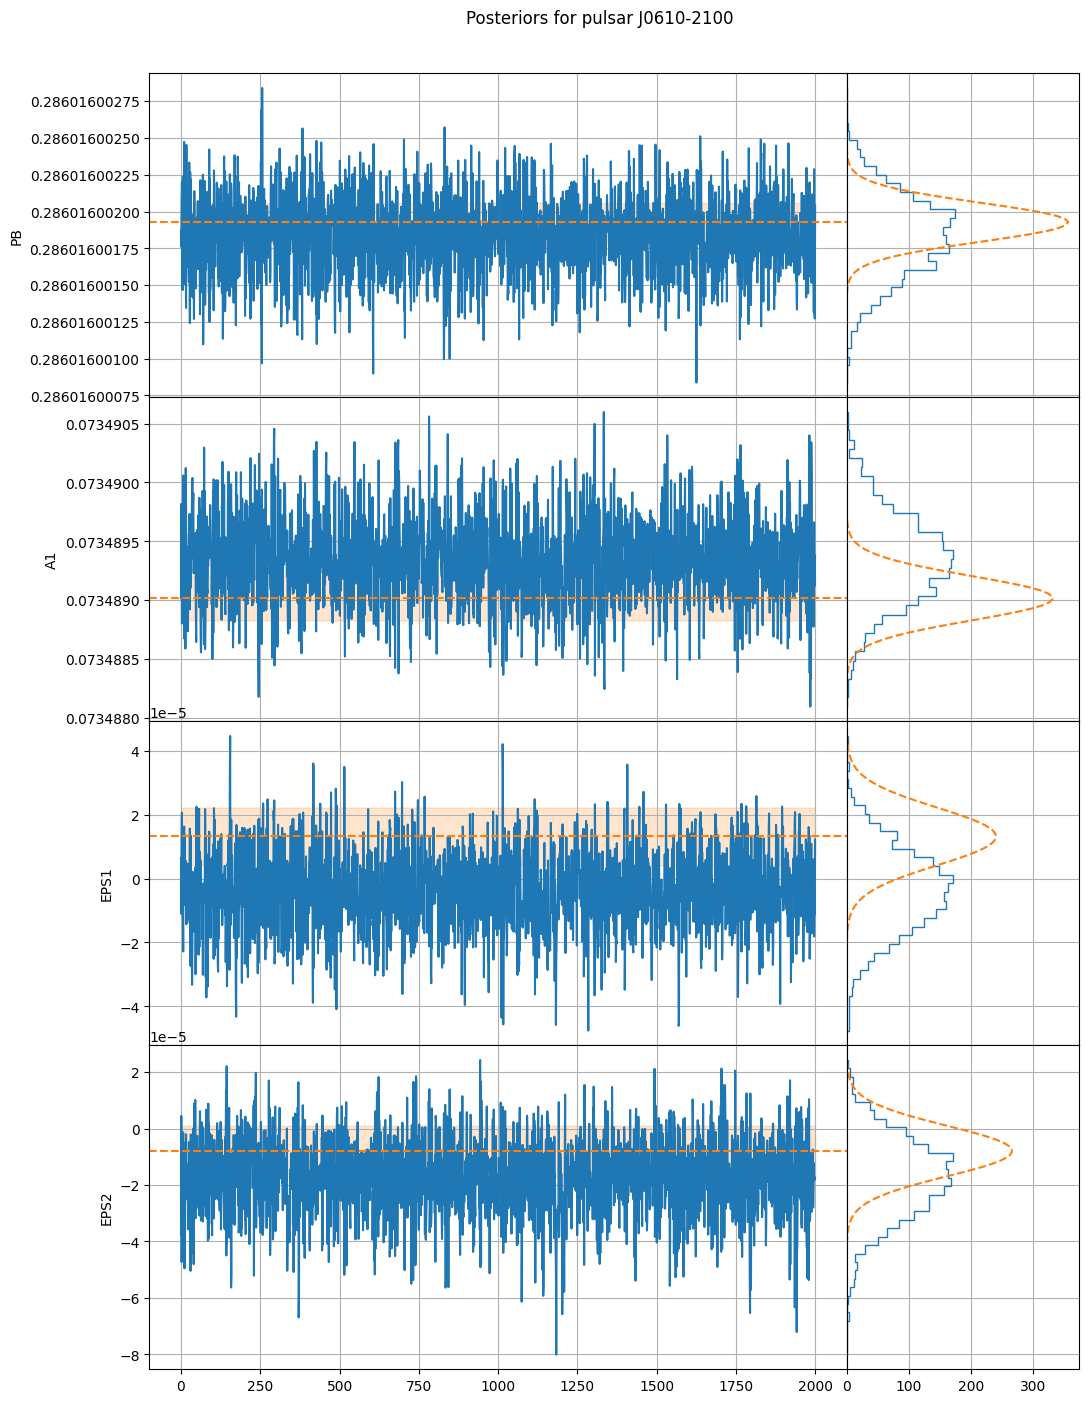

In [8]:
from scipy.stats import norm

for t in TM.per_psr_TM:
    chain = samples[f'{t.name}_thetab'] # (nbinary_par)
    theta = t.Mb_theta
    sigma = t.Mb_sigma
    labels = t.Mb_labels
    npar = len(labels)

    fig, axes = plt.subplots(npar, 2, figsize=(12, 4*npar), sharex='col',
                              gridspec_kw={'width_ratios': [3, 1]})
    if npar == 1:
        axes = axes[None, :]

    for i, l in enumerate(labels):
        c = chain[:, i]
        v = theta[i]
        s = sigma[i]
        n = norm(loc=v, scale=s)

        ax1, ax2 = axes[i, 0], axes[i, 1]
        ax2.sharey(ax1)

        ax1.plot(c)
        ax1.axhline(v, color='C1', linestyle='--')
        ax1.fill_between(range(len(c)), v-s, v+s, color='C1', alpha=0.2)
        ax1.set_ylabel(l)
        ax1.ticklabel_format(axis='y', useOffset=False)
        ax1.grid()

        y = np.linspace(min(c), max(c), 100)
        counts, bin_edges, _ = ax2.hist(c, bins='auto', density=False, histtype='step', orientation='horizontal')
        bin_width = bin_edges[1] - bin_edges[0]
        scale = len(c) * bin_width
        ax2.plot(n.pdf(y) * scale, y, color='C1', linestyle='--', label='PINT fit')
        ax2.tick_params(axis='y', left=False, labelleft=False)
        ax2.grid()

        if i != npar - 1:
            ax1.tick_params(axis='x', labelbottom=False)
            ax2.tick_params(axis='x', labelbottom=False)

    plt.subplots_adjust(wspace=0, hspace=0, top=0.92)
    plt.suptitle(f'Posteriors for pulsar {t.name}', y=0.96)
    plt.savefig(f'Posteriors_for_pulsar_{t.name}.png')
    plt.show()